<a href="https://colab.research.google.com/github/mdanmek/nida-dads-notes/blob/main/dads5001-data-tools/project/eda/05_construction_storytelling_visuals_2569.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


> **ผลลัพธ์ตัวอย่าง:** รูปและตารางด้านล่างมาจากไฟล์ที่ผู้จัดทำรันบน Google Colab และส่งมาใน `notebook_with_results` สามารถเปิดดูได้โดยไม่ต้องรันใหม่ โค้ดคำนวณยังคงเดิม ผลเมื่อรันใหม่ขึ้นกับข้อมูลและการตั้งค่าที่ใช้


## วิธีรันเวอร์ชัน GitHub

เปิด Notebook นี้ใน Google Colab แล้วเลือก **Runtime → Run all** ข้อมูลจะอ่านจาก [data_for_github](https://drive.google.com/drive/folders/1ssVrUcY4TiYee9T2B0pwgr5SwvPp_lAq) โดยดาวน์โหลดเฉพาะไฟล์ที่ใช้ลงพื้นที่ชั่วคราวของ Runtime ไม่ต้องตั้งโฟลเดอร์ผลลัพธ์หรือเชื่อม Drive ส่วนตัว

- กราฟและตารางแสดงใน Notebook ไม่มีการส่งออก CSV/PNG/SVG ไปยัง Drive หรือเครื่องของผู้อ่าน
- ไฟล์ข้อมูล ฟอนต์ แผนที่ และ CSV พักที่จำเป็นอยู่ใน Runtime เท่านั้น เซลล์สุดท้ายลบไฟล์พักและเก็บ DataFrame ไว้ให้วิเคราะห์ต่อ หากหยุดกลางทางให้รัน `cleanup_runtime()` เมื่อไม่ต้องใช้ไฟล์พักแล้ว
- รันแต่ละ Notebook ใน Runtime แยกกันเพื่อลด RAM; หาก RAM ใช้ถึง 80% โค้ดจะหยุดพร้อมคำแนะนำ แทนการฝืนประมวลผล
- กรณี Drive จำกัดการดาวน์โหลด ให้ดาวน์โหลดข้อมูลเองและระบุ `LOCAL_DATA_DIR` ในเซลล์ตั้งค่า
- สูตร เกณฑ์ ตัวกรอง และลำดับข้อมูลคงตามไฟล์ต้นฉบับ อ่านข้อแตกต่างระหว่าง Notebook และรายการไฟล์ใน [DATA_FILES.md](../DATA_FILES.md)

ผลลัพธ์เดิมที่ฝังในไฟล์ถูกล้างเพื่อให้ผู้อ่านเห็นผลจากการรันครั้งใหม่


In [1]:
# GitHub / Colab: ดาวน์โหลดข้อมูลเฉพาะที่ใช้ลงพื้นที่ชั่วคราว ไม่ต้อง Mount Drive
# เปลี่ยนเป็น Path โฟลเดอร์ข้อมูลที่มีอยู่แล้วได้ เพื่อไม่ต้องดาวน์โหลดซ้ำ
LOCAL_DATA_DIR = None
import atexit
import gc
import hashlib
import importlib.util
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

# ติดตั้งเฉพาะแพ็กเกจที่ยังไม่มี; subprocess นี้รอจนจบ ไม่มี worker ค้าง
_packages = {"pandas": "pandas>=2.2,<3", "numpy": "numpy", "matplotlib": "matplotlib", "seaborn": "seaborn", "geopandas": "geopandas", "psutil": "psutil", "gdown": "gdown", "IPython": "ipython"}
_missing_packages = [requirement for module, requirement in _packages.items() if importlib.util.find_spec(module) is None]
if _missing_packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing_packages], check=True)
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown
from IPython.display import display

def check_memory(stage="ประมวลผล"):
    # หยุดอย่างชัดเจนเมื่อ RAM สูง แทนการฝืนจน Runtime หลุด
    if psutil.virtual_memory().percent >= 80:
        gc.collect()
        if psutil.virtual_memory().percent >= 80:
            raise MemoryError(f"RAM ใช้เกิน 80% ก่อน {stage}; กรุณา Restart runtime หรือใช้ High-RAM แล้ว Run all ใหม่")

# รัน setup ซ้ำจะปิดพื้นที่ชั่วคราวของ Notebook รอบก่อน
if "_github_runtime" in globals():
    _github_runtime.cleanup()
_github_runtime = tempfile.TemporaryDirectory(prefix="procurement_github_")
atexit.register(_github_runtime.cleanup)
RUNTIME_DIR = Path(_github_runtime.name)
DATA_DIR = RUNTIME_DIR / "inputs"
DATA_DIR.mkdir()
_initial_figure_numbers = set(plt.get_fignums())

DATA_FILES = {
    "07_lower10_project_budget_2567.csv": {
        "id": "1YQpAhUcghJ9gM6eIC6qBZGe6WcVuKyWR",
        "size": 4169
    },
    "07_lower10_project_budget_2568.csv": {
        "id": "1aNYIMOH7Da8VvVhXI1XQigBYRNWk9IHj",
        "size": 5098
    },
    "07_lower10_project_budget_2569.csv": {
        "id": "1tU1V9n2ysJmXxvmnm_SPz7n7Bhbz2B5_",
        "size": 4371
    },
    "07_top10_project_budget_2567.csv": {
        "id": "1bkMYSpLM4UKivKCHe7S8Dsho0BaLgCdJ",
        "size": 5619
    },
    "07_top10_project_budget_2568.csv": {
        "id": "1xsItnomfe9q4A9NYJ5U_lR0764mZMEE4",
        "size": 5682
    },
    "07_top10_project_budget_2569.csv": {
        "id": "1ZwOBFVQkTRAnazjoeXzr3jkpSGFl2bkI",
        "size": 6385
    },
    "2569-egp-contract-1.csv": {
        "id": "1ygmuKsvVjNpjfg0k94Olcuox8efDP3cY",
        "size": 615601896
    },
    "2569-egp-contract-2.csv": {
        "id": "1DUAh8zAtUUV4Hm2yRplCryUOQDFb3Ad8",
        "size": 542097077
    },
    "2569-egp-contract-3.csv": {
        "id": "1fD_6GqtIY7LUempYqId0qIEldcJd2moM",
        "size": 529193616
    },
    "2569-egp-contract-4.csv": {
        "id": "19C4Ak8XNMvm2IBsr7TVpfexZE_1WBke5",
        "size": 526729581
    },
    "2569-egp-contract-5.csv": {
        "id": "1nsV7vqF8Um-QWKX_Q-kEQq6Z1BFDbK_y",
        "size": 521850128
    },
    "2569-egp-contract-6.csv": {
        "id": "1-0zhDZjF2chjeXuPoSVGQWNYtp8fVIzt",
        "size": 522697146
    },
    "2569-egp-contract-7.csv": {
        "id": "1gl9sx_1ve-n7e9M_mQaj0A7mMnk2P0yb",
        "size": 517466336
    },
    "2569-egp-contract-8.csv": {
        "id": "1z0icf65DY2e7WPmc_qV5PPLdUVyT1wdR",
        "size": 455588827
    },
    "construction_contract_review_indicators_2569.csv": {
        "id": "1nYgjub4kfLTyX_9gnz3dM2GZWUM67wRJ",
        "size": 247613515
    },
    "construction_contract_supplier_study_scope_2569.csv": {
        "id": "1dXH9N4ukZAabRQwl9nkQ-KidB1e80ZAh",
        "size": 243311179
    },
    "priority_review_contracts_2569.csv": {
        "id": "1prDQwSgkNCFqarTx0rkFuQK12Q5J2MT_",
        "size": 108598
    },
    "project_overview_2567.csv": {
        "id": "1hEr6tXWRBgEM-uK0dOEKvzIhBdKzHtnx",
        "size": 1685455822
    },
    "project_overview_2568.csv": {
        "id": "1WVh1etQtH45AemJE4J7mBCDOOT9QmQff",
        "size": 1448461110
    },
    "project_overview_2569.csv": {
        "id": "1h3Oah1ARYenycAJnLa1DTefzjMryQuJ5",
        "size": 1227718817
    },
    "repeated_near_500k_agency_supplier_2569.csv": {
        "id": "10fT6PqZbBa5mS4GEHHEOf8_qIeASToQk",
        "size": 364037
    }
}

def data_file(name):
    # ใช้ไฟล์ในเครื่องก่อนถ้าผู้ใช้ระบุโฟลเดอร์ โดยไม่แก้ไขไฟล์ต้นฉบับ
    if LOCAL_DATA_DIR is not None:
        candidate = Path(LOCAL_DATA_DIR) / name
        if candidate.is_file():
            return candidate
    if name not in DATA_FILES:
        raise FileNotFoundError(f"ยังไม่มีข้อมูล {name} ในชุดที่แชร์ กรุณาตรวจ DATA_FILES หรือ LOCAL_DATA_DIR")
    item = DATA_FILES[name]
    target = DATA_DIR / name
    if target.is_file():
        return target
    required_bytes = int(item["size"])
    if shutil.disk_usage(DATA_DIR).free < required_bytes + 512 * 1024**2:
        raise OSError(f"พื้นที่ชั่วคราวไม่พอสำหรับ {name}")
    partial = target.with_suffix(target.suffix + ".part")
    print(f"อ่านข้อมูล {name} ({required_bytes / 1024**2:,.1f} MB)")
    try:
        result = gdown.download(id=item["id"], output=str(partial), quiet=False)
        if result is None or not partial.is_file() or partial.stat().st_size != required_bytes:
            raise IOError(f"ดาวน์โหลด {name} ไม่ครบ หรือไฟล์ใน Drive เปลี่ยนรุ่น")
        if item.get("md5"):
            digest = hashlib.md5()
            with partial.open("rb") as stream:
                for block in iter(lambda: stream.read(4 * 1024**2), b""):
                    digest.update(block)
            if digest.hexdigest() != item["md5"]:
                raise IOError(f"Checksum ไม่ตรงสำหรับ {name}")
        partial.replace(target)
    except Exception as exc:
        partial.unlink(missing_ok=True)
        raise RuntimeError(f"อ่าน {name} ไม่สำเร็จ: ตรวจสิทธิ์ Anyone with the link ของโฟลเดอร์ข้อมูล หรือดาวน์โหลดเองแล้วกำหนด LOCAL_DATA_DIR") from exc
    return target

def release_download(path):
    # ลบเฉพาะสำเนาที่ Notebook นี้ดาวน์โหลด ไม่ลบไฟล์ใน LOCAL_DATA_DIR
    path = Path(path)
    if path.parent == DATA_DIR:
        path.unlink(missing_ok=True)

def cleanup_runtime():
    # เก็บ DataFrame ผลวิเคราะห์ไว้ให้ย้อนกลับมาดูต่อได้
    for number in set(plt.get_fignums()) - _initial_figure_numbers:
        plt.close(number)
    _github_runtime.cleanup()
    gc.collect()
    print("ปิดรูปและลบไฟล์พักของ Notebook แล้ว; DataFrame ผลวิเคราะห์ยังอยู่ใน RAM")

check_memory("เริ่ม Notebook")



# จากเพดานวงเงินสู่รายการตรวจสอบลำดับแรก

Notebook นี้เป็น **presentation layer** ของโครงการ DADS5001 โดยอ่านผลลัพธ์จาก Notebook 02–04 แล้วสร้าง visual ตามลำดับเรื่อง ไม่คำนวณนิยาม scope หรือ criteria ใหม่

เรื่องที่ต้องการเล่ามี 6 ช่วง:

1. จากรายการสัญญาก่อสร้างทั้งหมด เหลือขอบเขตศึกษาเท่าไร
2. รอบเพดาน 500,000 บาทเกิดอะไรขึ้น
3. รายการใกล้เพดานสัมพันธ์กับวิธีจัดซื้อใด
4. คู่หน่วยงาน–ผู้รับจ้างใดมีรายการใกล้เพดานเกิดซ้ำมาก
5. Pattern 1 และ Pattern 2 ซ้อนทับกันอย่างไร
6. คู่หน่วยงาน–ผู้รับจ้างใดควรเปิดเอกสารก่อน

ผลลัพธ์เป็นรายการสำหรับตรวจสอบต่อ ไม่ใช่หลักฐานการทุจริตหรือการแบ่งซื้อแบ่งจ้าง


In [2]:
# GitHub: ใช้ข้อมูลจากลิงก์ที่แชร์ ไม่ต้อง Mount Drive


In [3]:
from pathlib import Path
from textwrap import shorten

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ดาวน์โหลดฟอนต์ภาษาไทยสำหรับ Matplotlib
import urllib.request
_font_file = RUNTIME_DIR / 'thsarabunnew-webfont.ttf'
urllib.request.urlretrieve('https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf', _font_file)
fm.fontManager.addfont(str(_font_file))

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')


## 1. เปิดผลลัพธ์จาก Notebook 02–04

Notebook 05 ใช้ไฟล์ที่ผ่านการเตรียมข้อมูลและสร้าง flag แล้ว หากไฟล์ไม่ครบ ให้ Run all Notebook 02 → 03 → 04 ก่อน


In [4]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
# ใช้ผลลัพธ์ snapshot ของ Pae โดยตรง ไม่ต้องรัน Notebook อื่นหรือสร้างไฟล์ก่อน
processed_dir = DATA_DIR
figure_dir = RUNTIME_DIR
contract_path = data_file('construction_contract_supplier_study_scope_2569.csv')
flags_path = data_file('construction_contract_review_indicators_2569.csv')
repeated_pairs_path = data_file('repeated_near_500k_agency_supplier_2569.csv')
priority_path = data_file('priority_review_contracts_2569.csv')

required_paths = [
    contract_path,
    flags_path,
    repeated_pairs_path,
    priority_path
]

missing_paths = [path for path in required_paths if not path.exists()]

if missing_paths:
    missing_text = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(
        'ไม่พบไฟล์ผลลัพธ์ต่อไปนี้ กรุณา Run all Notebook 02–04 ก่อน:\n'
        f'{missing_text}'
    )

contract_data = pd.read_csv(contract_path, low_memory=False)
contract_flags = pd.read_csv(flags_path, low_memory=False)
repeated_pairs = pd.read_csv(repeated_pairs_path, low_memory=False)
priority_contracts = pd.read_csv(priority_path, low_memory=False)

file_summary = pd.DataFrame({
    'ข้อมูล': [
        'รายการสัญญาก่อสร้าง',
        'รายการพร้อม flag',
        'คู่หน่วยงาน–ผู้รับจ้างใกล้เพดานที่เกิดซ้ำ',
        'รายการตรวจสอบลำดับแรก'
    ],
    'จำนวนแถว': [
        len(contract_data),
        len(contract_flags),
        len(repeated_pairs),
        len(priority_contracts)
    ]
})

display(file_summary)


อ่านข้อมูล construction_contract_supplier_study_scope_2569.csv (232.0 MB)


อ่านข้อมูล construction_contract_review_indicators_2569.csv (236.1 MB)


อ่านข้อมูล repeated_near_500k_agency_supplier_2569.csv (0.3 MB)


อ่านข้อมูล priority_review_contracts_2569.csv (0.1 MB)


,ข้อมูล,จำนวนแถว
0,รายการสัญญาก่อสร้าง,179716
1,รายการพร้อม flag,179716
2,คู่หน่วยงาน–ผู้รับจ้างใกล้เพดานที่เกิดซ้ำ,1580
3,รายการตรวจสอบลำดับแรก,161


In [5]:
project_id_column = 'รหัสโครงการ'
contract_column = 'เลขที่สัญญา'
contract_value_column = 'วงเงินงบประมาณในสัญญา (บาท)'
method_column = 'ชื่อวิธีการจัดซื้อจัดจ้าง'
agency_column = 'ชื่อหน่วยงาน'
province_column = 'จังหวัด'
supplier_id_column = 'เลขประจำตัวนิติบุคคล 13 หลัก'
supplier_name_column = 'ชื่อผู้ชนะการเสนอราคา'
scope_column = 'อยู่ในขอบเขตตรวจรูปแบบ'

flag_columns = [
    'flag_pattern_1',
    'flag_pattern_2',
    'priority_review'
]

for column in flag_columns:
    contract_flags[column] = (
        contract_flags[column]
        .astype('boolean')
        .fillna(False)
    )

study_data = contract_data.loc[contract_data[scope_column]].copy()
near_ceiling_data = study_data.loc[
    study_data[contract_value_column].between(490000, 500000)
].copy()

print(f'รายการสัญญาก่อสร้างทั้งหมด: {len(contract_data):,}')
print(f'รายการในขอบเขตศึกษา: {len(study_data):,}')
print(f'รายการใกล้เพดาน: {len(near_ceiling_data):,}')
print(f'รายการตรวจสอบลำดับแรก: {len(priority_contracts):,}')


รายการสัญญาก่อสร้างทั้งหมด: 179,716
รายการในขอบเขตศึกษา: 136,122
รายการใกล้เพดาน: 20,200
รายการตรวจสอบลำดับแรก: 161


## 2. Visual theme

ใช้สีตามความหมายเดียวกันทุกภาพ:

- น้ำเงิน: ข้อมูลหลัก
- ส้ม: จุดใกล้เพดานหรือสิ่งที่ต้องสนใจ
- แดง: รายการตรวจสอบลำดับแรก
- เทา: ข้อมูลเปรียบเทียบ


In [6]:
FIG_SIZE = (12, 6.75)
EXPORT_DPI = 180
COLORS = {
    'primary': '#365F7D',
    'secondary': '#6F8FA6',
    'highlight': '#D9822B',
    'risk': '#B5473C',
    'neutral': '#98A2B3',
    'light': '#E4E7EC',
    'text': '#344054',
    'muted': '#667085',
    'background': '#FFFFFF'
}

plt.rcParams.update({
    'font.family': 'TH Sarabun New',
    'font.size': 12,
    'text.color': COLORS['text'],
    'axes.labelcolor': COLORS['text'],
    'axes.titlecolor': COLORS['text'],
    'axes.titlesize': 17,
    'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.color': COLORS['muted'],
    'ytick.color': COLORS['muted'],
    'axes.edgecolor': COLORS['light'],
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
    'grid.color': COLORS['light'],
    'grid.linewidth': 0.8,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'svg.fonttype': 'none',
    'axes.unicode_minus': False
})


def add_subtitle(ax, text):
    ax.text(
        0,
        1.01,
        text,
        transform=ax.transAxes,
        fontsize=11,
        color=COLORS['muted'],
        ha='left',
        va='bottom'
    )


def clean_axis(ax, grid_axis='x'):
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis=grid_axis, color=COLORS['light'])
    ax.grid(axis='y' if grid_axis == 'x' else 'x', visible=False)


def save_figure(fig, stem):
    png_path = figure_dir / f'{stem}.png'
    svg_path = figure_dir / f'{stem}.svg'

    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์
    pass  # GitHub: แสดงผลใน Notebook ไม่ส่งออกไฟล์

    print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")
    print("แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์")


## Story 1 — จากรายการก่อสร้างทั้งหมดเหลือขอบเขตศึกษาเท่าไร

ภาพแรกแสดงเฉพาะการลดขอบเขตข้อมูลแบบเป็นลำดับ ยังไม่รวม Pattern 1 และ Pattern 2 เพราะสอง Pattern เป็นเงื่อนไขที่ซ้อนทับกัน ไม่ใช่ funnel ต่อเนื่อง


แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


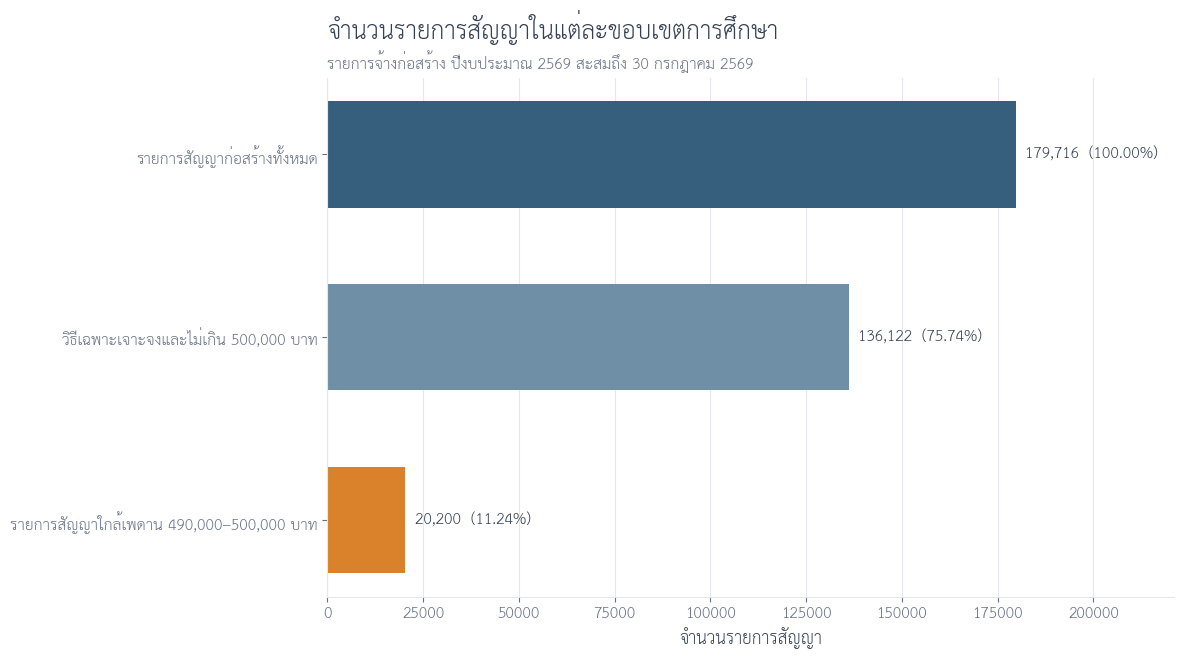

In [7]:
scope_story = pd.DataFrame({
    'ขั้นตอน': [
        'รายการสัญญาก่อสร้างทั้งหมด',
        'วิธีเฉพาะเจาะจงและไม่เกิน 500,000 บาท',
        'รายการสัญญาใกล้เพดาน 490,000–500,000 บาท'
    ],
    'จำนวนรายการ': [
        len(contract_data),
        len(study_data),
        len(near_ceiling_data)
    ]
})

scope_story['สัดส่วนจากรายการทั้งหมด (%)'] = (
    scope_story['จำนวนรายการ'] /
    len(contract_data) * 100
)

plot_data = scope_story.iloc[::-1].reset_index(drop=True)
bar_colors = [
    COLORS['highlight'],
    COLORS['secondary'],
    COLORS['primary']
]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['ขั้นตอน'],
    plot_data['จำนวนรายการ'],
    color=bar_colors,
    height=0.58
)

labels = [
    f'{count:,.0f}  ({share:.2f}%)'
    for count, share in zip(
        plot_data['จำนวนรายการ'],
        plot_data['สัดส่วนจากรายการทั้งหมด (%)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=7,
    fontsize=11,
    color=COLORS['text']
)

ax.set_title('จำนวนรายการสัญญาในแต่ละขอบเขตการศึกษา', pad=28)
add_subtitle(ax, 'รายการจ้างก่อสร้าง ปีงบประมาณ 2569 สะสมถึง 30 กรกฎาคม 2569')
ax.set_xlabel('จำนวนรายการสัญญา')
ax.set_ylabel('')
ax.set_xlim(0, plot_data['จำนวนรายการ'].max() * 1.23)
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_01_study_scope')
plt.show()
plt.close()  # คืนหน่วยความจำรูปที่แสดงเสร็จแล้ว


## Story 2 — รอบเพดาน 500,000 บาทเกิดอะไรขึ้น

ขยายเฉพาะช่วง 400,000–550,000 บาท เพื่อไม่ให้รายการมูลค่าสูงบดบังรูปทรงของข้อมูลบริเวณที่สนใจ


แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


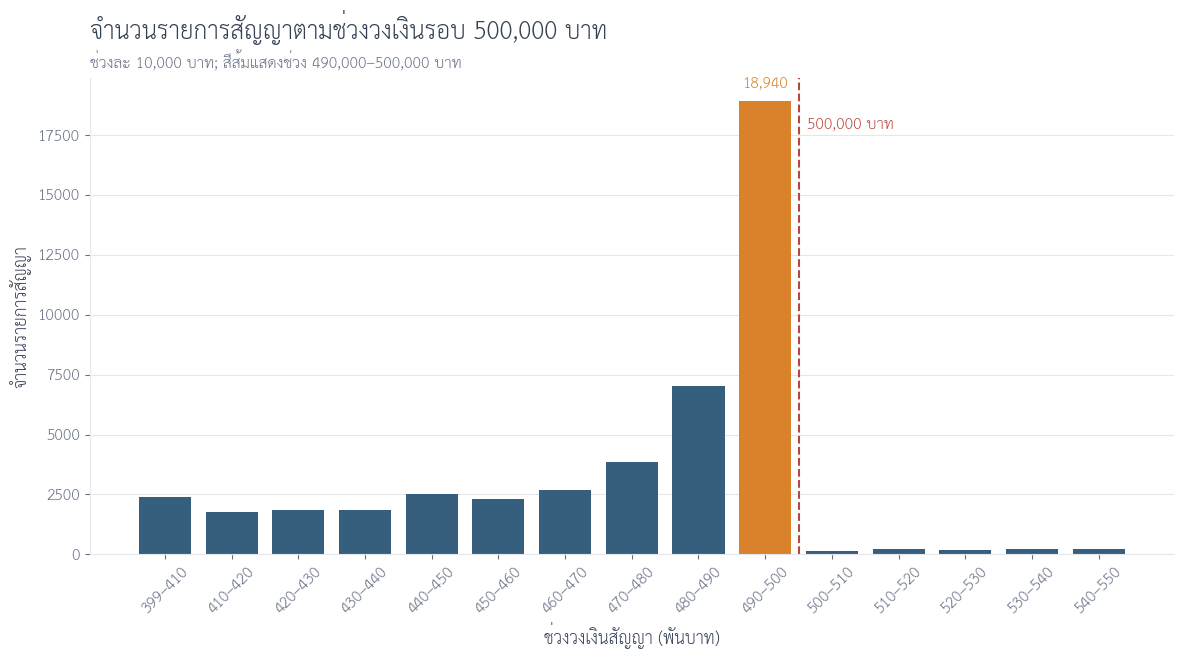

In [8]:
focus_data = contract_data.loc[
    contract_data[contract_value_column].between(400000, 550000)
].copy()

bin_edges = np.arange(400000, 560000, 10000)
focus_data['ช่วงวงเงิน'] = pd.cut(
    focus_data[contract_value_column],
    bins=bin_edges,
    right=True,
    include_lowest=True
)

band_counts = (
    focus_data['ช่วงวงเงิน']
    .value_counts(sort=False)
    .rename('จำนวนรายการ')
    .reset_index()
)

band_counts['label'] = [
    f'{int(interval.left / 1000):,}–{int(interval.right / 1000):,}'
    for interval in band_counts['ช่วงวงเงิน']
]

band_counts['ใกล้เพดาน'] = [
    interval.left >= 490000 and interval.right <= 500000
    for interval in band_counts['ช่วงวงเงิน']
]

colors = np.where(
    band_counts['ใกล้เพดาน'],
    COLORS['highlight'],
    COLORS['primary']
)

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.bar(
    band_counts['label'],
    band_counts['จำนวนรายการ'],
    color=colors,
    width=0.78
)

for bar, value, highlighted in zip(
    bars,
    band_counts['จำนวนรายการ'],
    band_counts['ใกล้เพดาน']
):
    if highlighted:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + band_counts['จำนวนรายการ'].max() * 0.02,
            f'{value:,.0f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='semibold',
            color=COLORS['highlight']
        )

ax.axvline(
    9.5,
    color=COLORS['risk'],
    linewidth=1.5,
    linestyle='--'
)
ax.text(
    9.62,
    ax.get_ylim()[1] * 0.90,
    '500,000 บาท',
    color=COLORS['risk'],
    fontsize=11,
    va='center'
)

ax.set_title('จำนวนรายการสัญญาตามช่วงวงเงินรอบ 500,000 บาท', pad=28)
add_subtitle(ax, 'ช่วงละ 10,000 บาท; สีส้มแสดงช่วง 490,000–500,000 บาท')
ax.set_xlabel('ช่วงวงเงินสัญญา (พันบาท)')
ax.set_ylabel('จำนวนรายการสัญญา')
ax.tick_params(axis='x', rotation=45)
clean_axis(ax, grid_axis='y')

fig.tight_layout()
save_figure(fig, 'fig05_02_contract_distribution_around_500k')
plt.show()
plt.close()  # คืนหน่วยความจำรูปที่แสดงเสร็จแล้ว


## Story 3 — รายการใกล้เพดานสัมพันธ์กับวิธีจัดซื้อใด

เปรียบเทียบเฉพาะรายการสัญญาช่วง 490,000–500,000 บาท และใช้สีส้มเน้นวิธีเฉพาะเจาะจง


แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


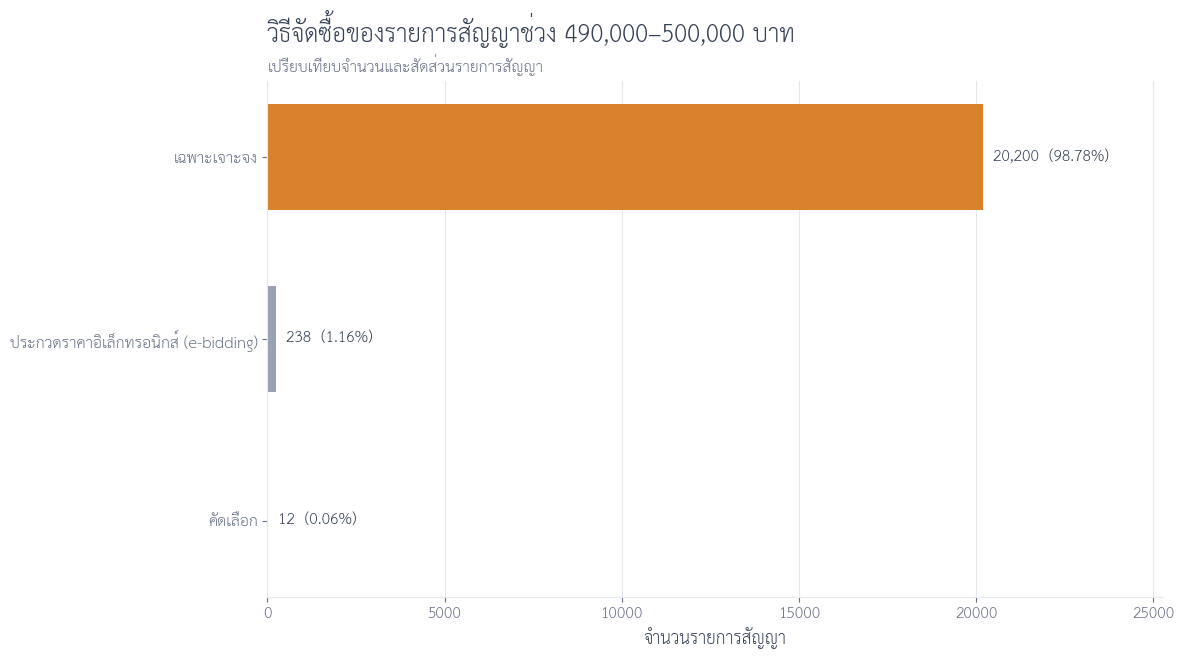

In [9]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
method_summary = (
    contract_data.loc[
        contract_data[contract_value_column].between(490000, 500000)
    ]
    .groupby(method_column, dropna=False)
    .agg({
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการ',
        contract_value_column: 'มูลค่ารวม'
    })
)

method_summary['สัดส่วนจำนวน (%)'] = (
    method_summary['จำนวนรายการ'] /
    method_summary['จำนวนรายการ'].sum() * 100
)

method_summary = (
    method_summary
    .sort_values('จำนวนรายการ')
    .reset_index(drop=True)
)

colors = [
    COLORS['highlight']
    if method == 'เฉพาะเจาะจง'
    else COLORS['neutral']
    for method in method_summary[method_column]
]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    method_summary[method_column],
    method_summary['จำนวนรายการ'],
    color=colors,
    height=0.58
)

labels = [
    f'{count:,.0f}  ({share:.2f}%)'
    for count, share in zip(
        method_summary['จำนวนรายการ'],
        method_summary['สัดส่วนจำนวน (%)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=7,
    fontsize=11,
    color=COLORS['text']
)

ax.set_title('วิธีจัดซื้อของรายการสัญญาช่วง 490,000–500,000 บาท', pad=28)
add_subtitle(ax, 'เปรียบเทียบจำนวนและสัดส่วนรายการสัญญา')
ax.set_xlabel('จำนวนรายการสัญญา')
ax.set_ylabel('')
ax.set_xlim(0, method_summary['จำนวนรายการ'].max() * 1.25)
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_03_method_near_500k')
plt.show()
plt.close()  # คืนหน่วยความจำรูปที่แสดงเสร็จแล้ว


## Story 4 — คู่หน่วยงาน–ผู้รับจ้างใดมีรายการใกล้เพดานเกิดซ้ำมาก

ภาพนี้จัดอันดับด้วยจำนวนรายการใกล้เพดาน ไม่ใช้สัดส่วนเป็นอันดับแรก เพราะต้องการแสดง exposure เชิงปริมาณ ส่วน label ด้านขวาแสดงสัดส่วนใกล้เพดานภายในคู่เดียวกัน


แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


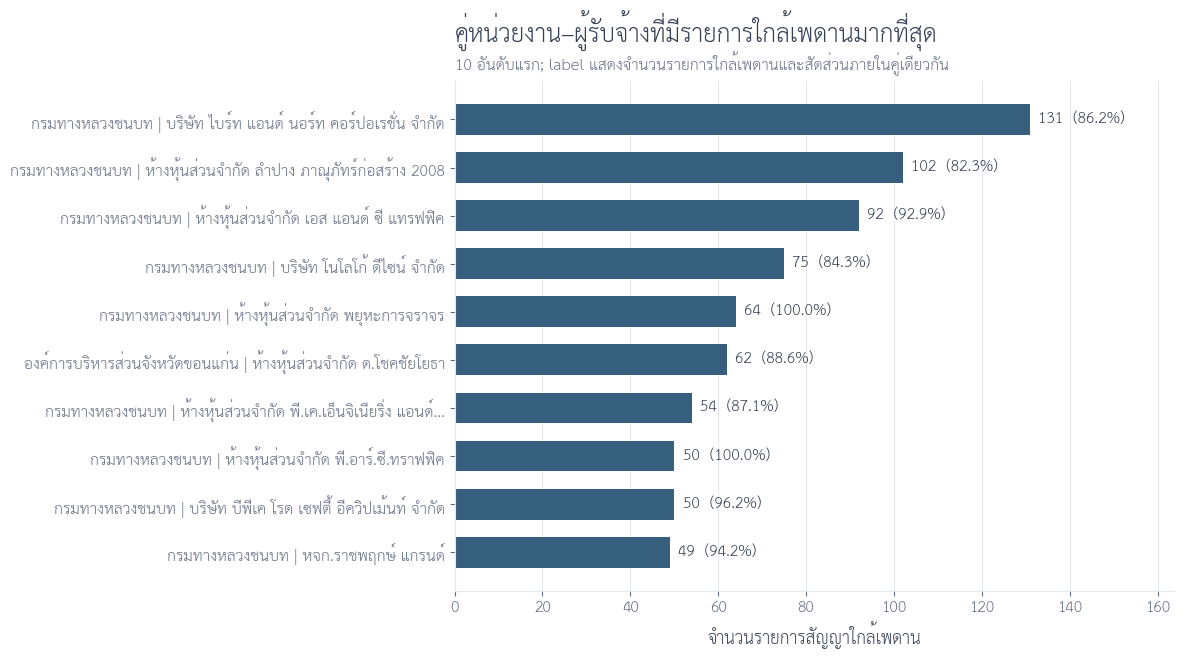

In [10]:
top_repeated_pairs = (
    repeated_pairs
    .sort_values(
        ['จำนวนสัญญาใกล้เพดาน', 'สัดส่วนจำนวนใกล้เพดาน (%)'],
        ascending=False
    )
    .head(10)
    .copy()
)

top_repeated_pairs['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=66,
        placeholder='…'
    )
    for agency, supplier in zip(
        top_repeated_pairs[agency_column],
        top_repeated_pairs[supplier_name_column]
    )
]

plot_data = top_repeated_pairs.iloc[::-1]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['คู่หน่วยงาน–ผู้รับจ้าง'],
    plot_data['จำนวนสัญญาใกล้เพดาน'],
    color=COLORS['primary'],
    height=0.64
)

labels = [
    f'{count:,.0f}  ({share:.1f}%)'
    for count, share in zip(
        plot_data['จำนวนสัญญาใกล้เพดาน'],
        plot_data['สัดส่วนจำนวนใกล้เพดาน (%)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=6,
    fontsize=11,
    color=COLORS['text']
)

ax.set_title('คู่หน่วยงาน–ผู้รับจ้างที่มีรายการใกล้เพดานมากที่สุด', pad=28)
add_subtitle(ax, '10 อันดับแรก; label แสดงจำนวนรายการใกล้เพดานและสัดส่วนภายในคู่เดียวกัน')
ax.set_xlabel('จำนวนรายการสัญญาใกล้เพดาน')
ax.set_ylabel('')
ax.set_xlim(0, plot_data['จำนวนสัญญาใกล้เพดาน'].max() * 1.25)
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_04_top_repeated_near_ceiling_pairs')
plt.show()
plt.close()  # คืนหน่วยความจำรูปที่แสดงเสร็จแล้ว


## Story 5 — Pattern 1 และ Pattern 2 ซ้อนทับกันอย่างไร

Pattern 1 และ Pattern 2 เป็นคนละเงื่อนไข จึงไม่ใช้ funnel ต่อกัน ภาพนี้แสดงสองเส้นทางที่มาบรรจบกันเป็น `priority_review`


แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


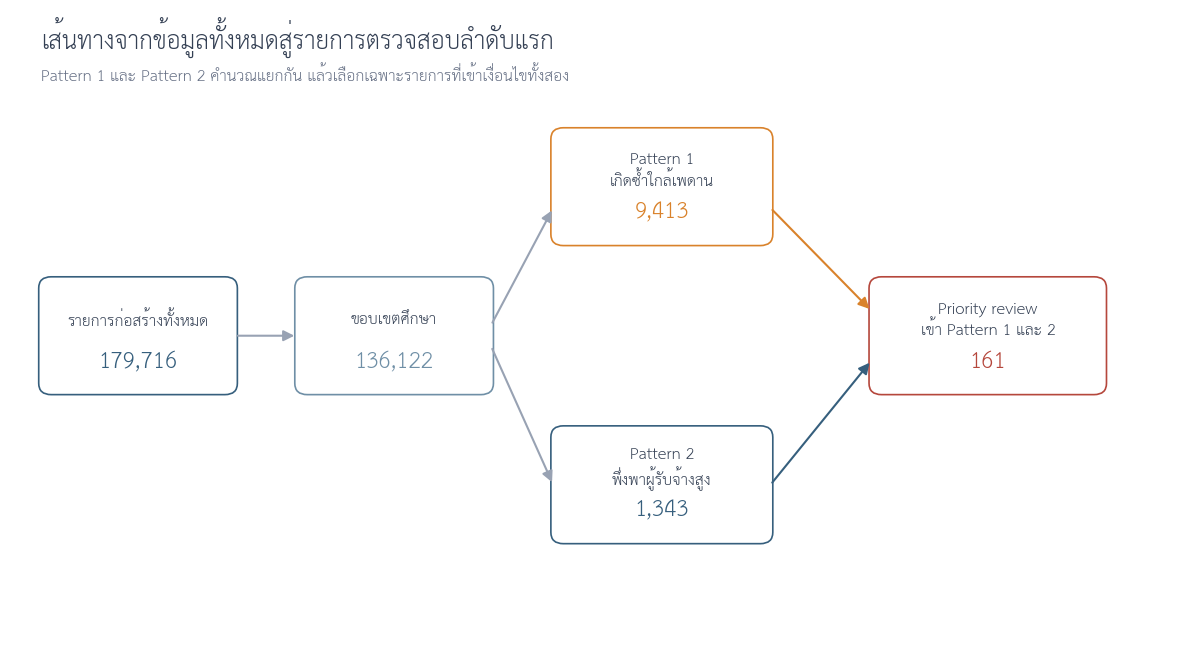

In [11]:
all_contract_count = len(contract_data)
study_count = int(contract_data[scope_column].sum())
near_count = len(near_ceiling_data)
pattern1_count = int(contract_flags['flag_pattern_1'].sum())
pattern2_count = int(contract_flags['flag_pattern_2'].sum())
priority_count = int(contract_flags['priority_review'].sum())

fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.set_xlim(0, 15)
ax.set_ylim(0, 9)
ax.axis('off')


def add_box(x, y, width, height, title, value, color):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle='round,pad=0.03,rounding_size=0.16',
        linewidth=1.2,
        edgecolor=color,
        facecolor='white'
    )
    ax.add_patch(box)
    ax.text(
        x + width / 2,
        y + height * 0.64,
        title,
        ha='center',
        va='center',
        fontsize=11,
        color=COLORS['text']
    )
    ax.text(
        x + width / 2,
        y + height * 0.28,
        f'{value:,.0f}',
        ha='center',
        va='center',
        fontsize=16,
        fontweight='semibold',
        color=color
    )


def add_arrow(start, end, color=COLORS['neutral']):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle='-|>',
        mutation_scale=16,
        linewidth=1.5,
        color=color,
        connectionstyle='arc3,rad=0.0'
    )
    ax.add_patch(arrow)


add_box(0.4, 3.6, 2.5, 1.6, 'รายการก่อสร้างทั้งหมด', all_contract_count, COLORS['primary'])
add_box(3.7, 3.6, 2.5, 1.6, 'ขอบเขตศึกษา', study_count, COLORS['secondary'])
add_box(7.0, 5.7, 2.8, 1.6, 'Pattern 1\nเกิดซ้ำใกล้เพดาน', pattern1_count, COLORS['highlight'])
add_box(7.0, 1.5, 2.8, 1.6, 'Pattern 2\nพึ่งพาผู้รับจ้างสูง', pattern2_count, COLORS['primary'])
add_box(11.1, 3.6, 3.0, 1.6, 'Priority review\nเข้า Pattern 1 และ 2', priority_count, COLORS['risk'])

add_arrow((2.9, 4.4), (3.7, 4.4))
add_arrow((6.2, 4.55), (7.0, 6.2))
add_arrow((6.2, 4.25), (7.0, 2.3))
add_arrow((9.8, 6.2), (11.1, 4.75), COLORS['highlight'])
add_arrow((9.8, 2.3), (11.1, 4.05), COLORS['primary'])

ax.text(
    0.4,
    8.45,
    'เส้นทางจากข้อมูลทั้งหมดสู่รายการตรวจสอบลำดับแรก',
    fontsize=17,
    fontweight='semibold',
    color=COLORS['text'],
    ha='left'
)
ax.text(
    0.4,
    8.0,
    'Pattern 1 และ Pattern 2 คำนวณแยกกัน แล้วเลือกเฉพาะรายการที่เข้าเงื่อนไขทั้งสอง',
    fontsize=11,
    color=COLORS['muted'],
    ha='left'
)

fig.tight_layout()
save_figure(fig, 'fig05_05_review_filtering_journey')
plt.show()


## Story 6 — คู่หน่วยงาน–ผู้รับจ้างใดควรเปิดเอกสารก่อน

จัดอันดับ 161 รายการใน `priority_review` ตามจำนวนรายการของคู่หน่วยงาน–ผู้รับจ้าง เพื่อกำหนดลำดับการเปิดเอกสาร ไม่ใช่จัดอันดับความทุจริต


แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์
แสดงผลใน Notebook; ไม่บันทึกไฟล์ผลลัพธ์


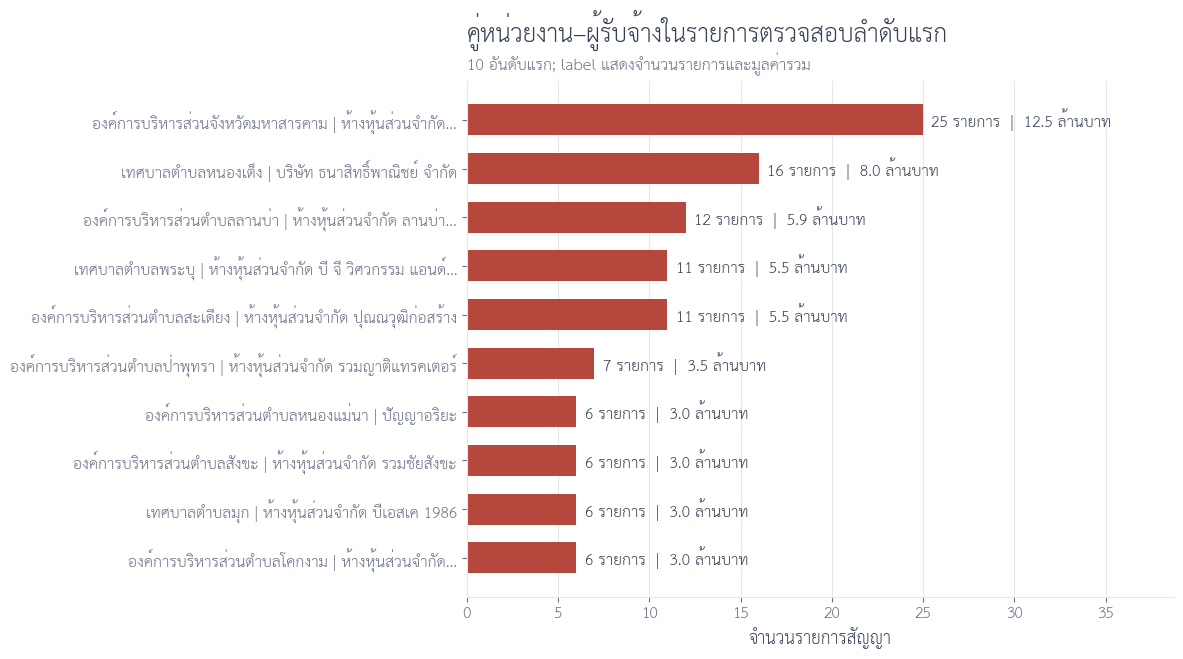

,ชื่อหน่วยงาน,เลขประจำตัวนิติบุคคล 13 หลัก,ชื่อผู้ชนะการเสนอราคา,จำนวนรายการตรวจสอบ,มูลค่ารวม (บาท),คู่หน่วยงาน–ผู้รับจ้าง
0,องค์การบริหารส่วนจังหวัดมหาสารคาม,443563000022,ห้างหุ้นส่วนจำกัด เจริญทรัพย์มหาสารคาม ก่อสร้าง,25,"12,454,000.00",องค์การบริหารส่วนจังหวัดมหาสารคาม | ห้างหุ้นส่วนจำกัด…
20,เทศบาลตำบลหนองเต็ง,315567000054,บริษัท ธนาสิทธิ์พาณิชย์ จำกัด,16,"7,952,000.00",เทศบาลตำบลหนองเต็ง | บริษัท ธนาสิทธิ์พาณิชย์ จำกัด
7,องค์การบริหารส่วนตำบลลานบ่า,673540000245,ห้างหุ้นส่วนจำกัด ลานบ่า คอนสตรัคชั่น,12,"5,914,000.00",องค์การบริหารส่วนตำบลลานบ่า | ห้างหุ้นส่วนจำกัด ลานบ่า…
17,เทศบาลตำบลพระบุ,403564002550,ห้างหุ้นส่วนจำกัด บี จี วิศวกรรม แอนด์ คอนสตรัคชั่น,11,"5,475,400.00",เทศบาลตำบลพระบุ | ห้างหุ้นส่วนจำกัด บี จี วิศวกรรม แอนด์…
8,องค์การบริหารส่วนตำบลสะเดียง,673543000441,ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง,11,"5,454,000.00",องค์การบริหารส่วนตำบลสะเดียง | ห้างหุ้นส่วนจำกัด ปุณณวุฒิก่อสร้าง
5,องค์การบริหารส่วนตำบลป่าพุทรา,623532000029,ห้างหุ้นส่วนจำกัด รวมญาติแทรคเตอร์,7,"3,465,500.00",องค์การบริหารส่วนตำบลป่าพุทรา | ห้างหุ้นส่วนจำกัด รวมญาติแทรคเตอร์
11,องค์การบริหารส่วนตำบลหนองแม่นา,673568000100,ปัญญาอริยะ,6,"2,997,000.00",องค์การบริหารส่วนตำบลหนองแม่นา | ปัญญาอริยะ
9,องค์การบริหารส่วนตำบลสังขะ,323534000151,ห้างหุ้นส่วนจำกัด รวมชัยสังขะ,6,"2,982,400.00",องค์การบริหารส่วนตำบลสังขะ | ห้างหุ้นส่วนจำกัด รวมชัยสังขะ
18,เทศบาลตำบลมุก,493567000167,ห้างหุ้นส่วนจำกัด บีเอสเค 1986,6,"2,969,200.00",เทศบาลตำบลมุก | ห้างหุ้นส่วนจำกัด บีเอสเค 1986
15,องค์การบริหารส่วนตำบลโคกงาม,423542000171,ห้างหุ้นส่วนจำกัด เบ๊นซ์วัสดุก่อสร้าง,6,"2,962,000.00",องค์การบริหารส่วนตำบลโคกงาม | ห้างหุ้นส่วนจำกัด…


In [12]:
# ตรวจ RAM ก่อนอ่านหรือรวมข้อมูลขนาดใหญ่
check_memory()
priority_pair_summary = (
    priority_contracts
    .groupby(
        [agency_column, supplier_id_column],
        dropna=False
    )
    .agg({
        supplier_name_column: 'first',
        contract_column: 'size',
        contract_value_column: 'sum'
    })
    .reset_index()
    .rename(columns={
        contract_column: 'จำนวนรายการตรวจสอบ',
        contract_value_column: 'มูลค่ารวม (บาท)'
    })
    .sort_values(
        ['จำนวนรายการตรวจสอบ', 'มูลค่ารวม (บาท)'],
        ascending=False
    )
    .head(10)
    .copy()
)

priority_pair_summary['คู่หน่วยงาน–ผู้รับจ้าง'] = [
    shorten(
        f'{agency} | {supplier}',
        width=66,
        placeholder='…'
    )
    for agency, supplier in zip(
        priority_pair_summary[agency_column],
        priority_pair_summary[supplier_name_column]
    )
]

plot_data = priority_pair_summary.iloc[::-1]

fig, ax = plt.subplots(figsize=FIG_SIZE)

bars = ax.barh(
    plot_data['คู่หน่วยงาน–ผู้รับจ้าง'],
    plot_data['จำนวนรายการตรวจสอบ'],
    color=COLORS['risk'],
    height=0.64
)

labels = [
    f'{count:,.0f} รายการ  |  {value / 1_000_000:,.1f} ล้านบาท'
    for count, value in zip(
        plot_data['จำนวนรายการตรวจสอบ'],
        plot_data['มูลค่ารวม (บาท)']
    )
]

ax.bar_label(
    bars,
    labels=labels,
    padding=6,
    fontsize=11,
    color=COLORS['text']
)

ax.set_title('คู่หน่วยงาน–ผู้รับจ้างในรายการตรวจสอบลำดับแรก', pad=28)
add_subtitle(ax, '10 อันดับแรก; label แสดงจำนวนรายการและมูลค่ารวม')
ax.set_xlabel('จำนวนรายการสัญญา')
ax.set_ylabel('')
ax.set_xlim(0, plot_data['จำนวนรายการตรวจสอบ'].max() * 1.55)
clean_axis(ax, grid_axis='x')

fig.tight_layout()
save_figure(fig, 'fig05_06_top_priority_pairs')
plt.show()
plt.close()  # คืนหน่วยความจำรูปที่แสดงเสร็จแล้ว

display(priority_pair_summary)


## สรุปการใช้ภาพ

| Figure | หน้าที่ในเรื่อง |
|---|---|
| `fig05_01_study_scope` | แสดงการลดขอบเขตข้อมูลก่อนเริ่ม Pattern |
| `fig05_02_contract_distribution_around_500k` | แสดงรูปทรงของข้อมูลรอบเพดาน 500,000 บาท |
| `fig05_03_method_near_500k` | เชื่อมการกระจุกใกล้เพดานกับวิธีจัดซื้อ |
| `fig05_04_top_repeated_near_ceiling_pairs` | แสดงคู่หน่วยงาน–ผู้รับจ้างที่มี exposure สูง |
| `fig05_05_review_filtering_journey` | อธิบายการซ้อนทับ Pattern 1 และ Pattern 2 |
| `fig05_06_top_priority_pairs` | จัดลำดับคู่ที่ควรเปิดเอกสารก่อน |

ภาพทั้งหมดบันทึกเป็น PNG และ SVG ในโฟลเดอร์ `project_1_dads5001/figure`


In [13]:
# คืนพื้นที่ชั่วคราวและปิดรูป โดยเก็บ DataFrame ผลวิเคราะห์ไว้
cleanup_runtime()


ปิดรูปและลบไฟล์พักของ Notebook แล้ว; DataFrame ผลวิเคราะห์ยังอยู่ใน RAM
